## **011963 ML for Civil and Environmental Engineering**

#### **05. Missing Data Imputation**
#### **Made by SSJin (2026.03.25)**
#### Sejong University, Dept. of Civil & Environmental Engineering

---

> **Convention:**
> - <font color='blue'>**Blue = Example**</font>: Worked examples with complete code.
> - <font color='red'>**Red = Exercise**</font>: Fill in the blanks (`________`).
> - Answer keys are at the bottom.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

---
#### **0 - Introduction**

Real-world datasets almost always contain **missing values**. Sensors malfunction, surveys go unanswered, and records get corrupted. Before feeding data into an ML model, we must handle these gaps.

This lab covers:
1. **Types** of missing values (MCAR, MAR, MNAR)
2. **Univariate** imputation (mean, median, mode, ffill/bfill, rolling)
3. **Multivariate** imputation (KNN, Iterative/MICE)
4. **Applied** imputation on a weather/construction dataset

---
#### **1 - Types of Missing Values**

| Type | Abbreviation | Description | Example |
|------|-------------|-------------|----------|
| Missing Completely at Random | **MCAR** | Missingness is unrelated to any variable | Sensor battery died randomly |
| Missing at Random | **MAR** | Missingness depends on **observed** data | Older sensors fail more often (age is observed) |
| Missing Not at Random | **MNAR** | Missingness depends on the **missing value itself** | Very high stress readings cause sensor overflow |

The type of missingness determines which imputation strategy is appropriate:

| Missingness | Safe Strategies | Risky Strategies |
|-------------|----------------|------------------|
| MCAR | Any method works | — |
| MAR | Model-based (KNN, MICE) | Simple mean/median |
| MNAR | Domain-specific handling | Most methods biased |

---
#### **2 - Univariate Imputation Methods**

Univariate methods use **only the values in the same column** to fill missing entries.

##### **2.0 Sample Dataset (Employee Data)**

<font color='blue'>**Example) Create a sample dataset with missing values**</font>

In [74]:
# Employee dataset (no external CSV needed)
df_raw = pd.DataFrame({
    'Country': ['Germany', 'Australia', 'Australia', 'Germany', 'Spain',
                'Germany', 'Australia', 'Spain', 'Germany', 'Australia'],
    'Age':     [44.0, 34.0, 30.0, 38.0, 40.0, np.nan, 48.0, 40.0, np.nan, 37.0],
    'Salary':  [72000, 48000, 54000, 61000, np.nan, 58000, 52000, np.nan, 79000, 67000],
    'Purchased': ['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
})

print('=== Raw Dataset ===')
print(df_raw)
print(f'\nMissing values:\n{df_raw.isnull().sum()}')

=== Raw Dataset ===
     Country   Age   Salary Purchased
0    Germany  44.0  72000.0        No
1  Australia  34.0  48000.0       Yes
2  Australia  30.0  54000.0        No
3    Germany  38.0  61000.0        No
4      Spain  40.0      NaN       Yes
5    Germany   NaN  58000.0       Yes
6  Australia  48.0  52000.0        No
7      Spain  40.0      NaN       Yes
8    Germany   NaN  79000.0        No
9  Australia  37.0  67000.0       Yes

Missing values:
Country      0
Age          2
Salary       2
Purchased    0
dtype: int64


##### **2.1 Method #1: Mean Imputation**

Replace missing values with the **column mean**.

$$x_{\text{filled}} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Pros**: Simple, preserves the mean.  
**Cons**: Reduces variance, ignores relationships between features.

<font color='blue'>**Example) Mean imputation for Age and Salary**</font>

In [75]:
cols = ['Age', 'Salary']
df = df_raw.copy()

fill_values = df[cols].mean()
for col in cols:
    df[col].fillna(fill_values[col], inplace=True)

print('Mean values used:', dict(fill_values.round(2)))
print()
print(df)

Mean values used: {'Age': 38.88, 'Salary': 61375.0}

     Country     Age   Salary Purchased
0    Germany  44.000  72000.0        No
1  Australia  34.000  48000.0       Yes
2  Australia  30.000  54000.0        No
3    Germany  38.000  61000.0        No
4      Spain  40.000  61375.0       Yes
5    Germany  38.875  58000.0       Yes
6  Australia  48.000  52000.0        No
7      Spain  40.000  61375.0       Yes
8    Germany  38.875  79000.0        No
9  Australia  37.000  67000.0       Yes


##### **2.2 Method #2: Median Imputation**

More **robust to outliers** than the mean.

<font color='blue'>**Example) Median imputation**</font>

In [76]:
df = df_raw.copy()
fill_values = df[cols].median()
for col in cols:
    df[col].fillna(fill_values[col], inplace=True)

print('Median values used:', dict(fill_values.round(2)))
print()
print(df)

Median values used: {'Age': 39.0, 'Salary': 59500.0}

     Country   Age   Salary Purchased
0    Germany  44.0  72000.0        No
1  Australia  34.0  48000.0       Yes
2  Australia  30.0  54000.0        No
3    Germany  38.0  61000.0        No
4      Spain  40.0  59500.0       Yes
5    Germany  39.0  58000.0       Yes
6  Australia  48.0  52000.0        No
7      Spain  40.0  59500.0       Yes
8    Germany  39.0  79000.0        No
9  Australia  37.0  67000.0       Yes


##### **2.3 Method #3: Mode Imputation**

Best for **categorical** or **discrete** data — fills with the most frequent value.

<font color='blue'>**Example) Mode imputation**</font>

In [77]:
df = df_raw.copy()
fill_values = df[cols].mode().iloc[0]
for col in cols:
    df[col].fillna(fill_values[col], inplace=True)

print('Mode values used:', dict(fill_values))
print()
print(df)

Mode values used: {'Age': 40.0, 'Salary': 48000.0}

     Country   Age   Salary Purchased
0    Germany  44.0  72000.0        No
1  Australia  34.0  48000.0       Yes
2  Australia  30.0  54000.0        No
3    Germany  38.0  61000.0        No
4      Spain  40.0  48000.0       Yes
5    Germany  40.0  58000.0       Yes
6  Australia  48.0  52000.0        No
7      Spain  40.0  48000.0       Yes
8    Germany  40.0  79000.0        No
9  Australia  37.0  67000.0       Yes


##### **2.4 Method #4: Forward Fill (ffill) and Backward Fill (bfill)**

- **Forward fill**: Use the **previous** valid value
- **Backward fill**: Use the **next** valid value

Best for **time-series** data where temporal order matters.

<font color='blue'>**Example) Forward fill and backward fill**</font>

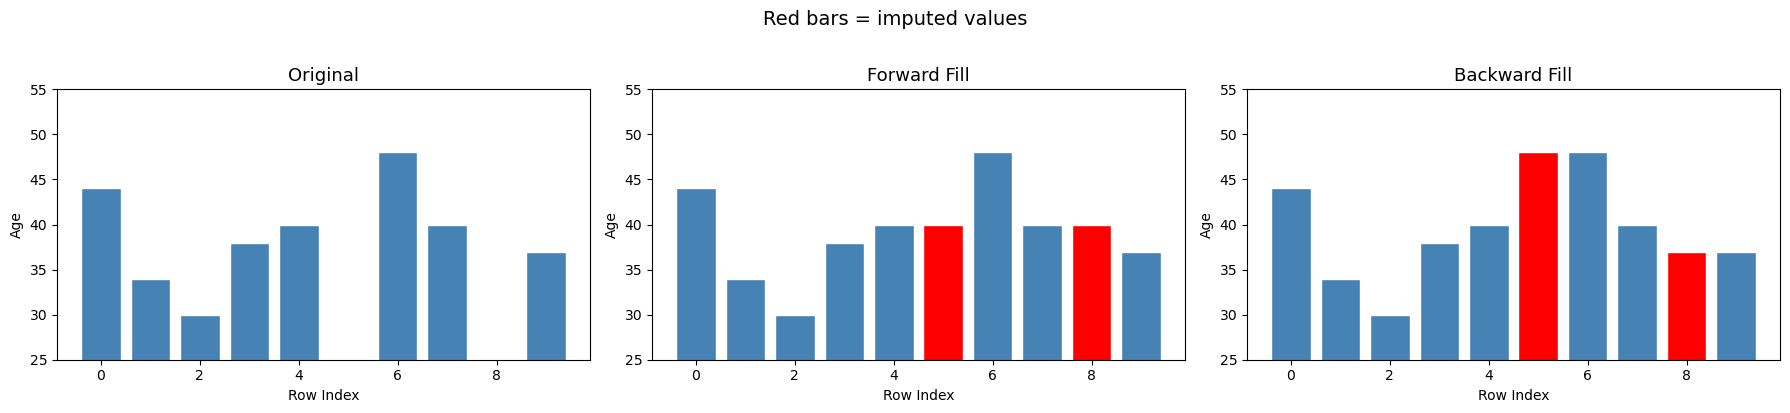

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (title, method) in zip(axes, [('Original', None), ('Forward Fill', 'ffill'), ('Backward Fill', 'bfill')]):
    df = df_raw.copy()
    if method == 'ffill':
        for col in cols: df[col] = df[col].ffill()
    elif method == 'bfill':
        for col in cols: df[col] = df[col].bfill()
    
    # Visualize Age column
    colors = ['red' if pd.isna(df_raw.loc[i, 'Age']) else 'steelblue' for i in range(len(df))]
    ax.bar(range(len(df)), df['Age'], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Row Index'); ax.set_ylabel('Age')
    ax.set_ylim(25, 55)
    
plt.suptitle('Red bars = imputed values', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

##### **2.5 Method #5: Rolling Mean Imputation**

Uses a **moving window** average. Good for smoothly varying time-series.

<font color='blue'>**Example) Rolling mean imputation (window=3)**</font>

In [79]:
df = df_raw.copy()
for col in cols:
    df[col] = df[col].fillna(df[col].rolling(window=3, min_periods=1).mean())

print(df)

     Country   Age   Salary Purchased
0    Germany  44.0  72000.0        No
1  Australia  34.0  48000.0       Yes
2  Australia  30.0  54000.0        No
3    Germany  38.0  61000.0        No
4      Spain  40.0  57500.0       Yes
5    Germany  39.0  58000.0       Yes
6  Australia  48.0  52000.0        No
7      Spain  40.0  55000.0       Yes
8    Germany  44.0  79000.0        No
9  Australia  37.0  67000.0       Yes


<font color='red'>**Exercise 2.1) Compare mean, median, and mode imputation for the `Salary` column. Which gives the most different result?**</font>

In [80]:
df_mean = df_raw.copy()
df_median = df_raw.copy()
df_mode = df_raw.copy()

df_mean['Salary'] = df_mean['Salary'].fillna(df_mean['Salary'].mean())
df_median['Salary'] = df_median['Salary'].fillna(df_median['Salary'].median())
df_mode['Salary'] = df_mode['Salary'].fillna(df_mode['Salary'].mode().iloc[0])

# Find the row where Salary was missing (row index 4)
idx = df_raw[df_raw['Salary'].isna()].index[0]
print(f'Original: NaN')
print(f'Mean imputed:   {df_mean.loc[idx, "Salary"]:.0f}')
print(f'Median imputed: {df_median.loc[idx, "Salary"]:.0f}')
print(f'Mode imputed:   {df_mode.loc[idx, "Salary"]:.0f}')

Original: NaN
Mean imputed:   61375
Median imputed: 59500
Mode imputed:   48000


---
#### **3 - Multivariate Imputation Methods**

Multivariate methods use **information from other columns** to estimate missing values.

##### **3.1 Method #6: KNN Imputation**

Finds the $k$ **nearest neighbors** (based on non-missing features) and uses their average.

**Pros**: Captures relationships between features.  
**Cons**: Requires all features to be numeric (encode categoricals first).

<font color='blue'>**Example) KNN imputation with k=3**</font>

In [81]:
from sklearn.impute import KNNImputer

# Prepare: one-hot encode categorical columns first
df = df_raw.copy()
df = pd.get_dummies(df, prefix=['Country'], columns=['Country'], drop_first=True, dtype=float)
df = pd.get_dummies(df, prefix=['Purchased'], columns=['Purchased'], drop_first=True, dtype=float)
print('Before KNN imputation:')
print(df)
print()

# KNN Imputer (k=3)
knn_imputer = KNNImputer(n_neighbors=3)
df_filled = pd.DataFrame(knn_imputer.fit_transform(df), columns=df.columns)

print('After KNN imputation:')
print(df_filled)

Before KNN imputation:
    Age   Salary  Country_Germany  Country_Spain  Purchased_Yes
0  44.0  72000.0              1.0            0.0            0.0
1  34.0  48000.0              0.0            0.0            1.0
2  30.0  54000.0              0.0            0.0            0.0
3  38.0  61000.0              1.0            0.0            0.0
4  40.0      NaN              0.0            1.0            1.0
5   NaN  58000.0              1.0            0.0            1.0
6  48.0  52000.0              0.0            0.0            0.0
7  40.0      NaN              0.0            1.0            1.0
8   NaN  79000.0              1.0            0.0            0.0
9  37.0  67000.0              0.0            0.0            1.0

After KNN imputation:
         Age   Salary  Country_Germany  Country_Spain  Purchased_Yes
0  44.000000  72000.0              1.0            0.0            0.0
1  34.000000  48000.0              0.0            0.0            1.0
2  30.000000  54000.0              0.0     

##### **3.2 Method #7: Iterative Imputation (MICE)**

**MICE** (Multiple Imputation by Chained Equations) models each feature with missing values as a function of **all other features**, and iterates until convergence.

This is the most sophisticated univariate/multivariate hybrid method.

<font color='blue'>**Example) Iterative (MICE) imputation**</font>

In [82]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = df_raw.copy()
df = pd.get_dummies(df, prefix=['Country'], columns=['Country'], drop_first=True, dtype=float)
df = pd.get_dummies(df, prefix=['Purchased'], columns=['Purchased'], drop_first=True, dtype=float)

imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print('After MICE imputation:')
print(df_imputed)

After MICE imputation:
         Age        Salary  Country_Germany  Country_Spain  Purchased_Yes
0  44.000000  72000.000000              1.0            0.0            0.0
1  34.000000  48000.000000              0.0            0.0            1.0
2  30.000000  54000.000000              0.0            0.0            0.0
3  38.000000  61000.000000              1.0            0.0            0.0
4  40.000000  61375.001485              0.0            1.0            1.0
5  38.561387  58000.000000              1.0            0.0            1.0
6  48.000000  52000.000000              0.0            0.0            0.0
7  40.000000  61375.001485              0.0            1.0            1.0
8  42.693693  79000.000000              1.0            0.0            0.0
9  37.000000  67000.000000              0.0            0.0            1.0


##### **3.3 Comparison of All Methods**

<font color='blue'>**Example) Visual comparison: How does each method fill the missing Age values?**</font>

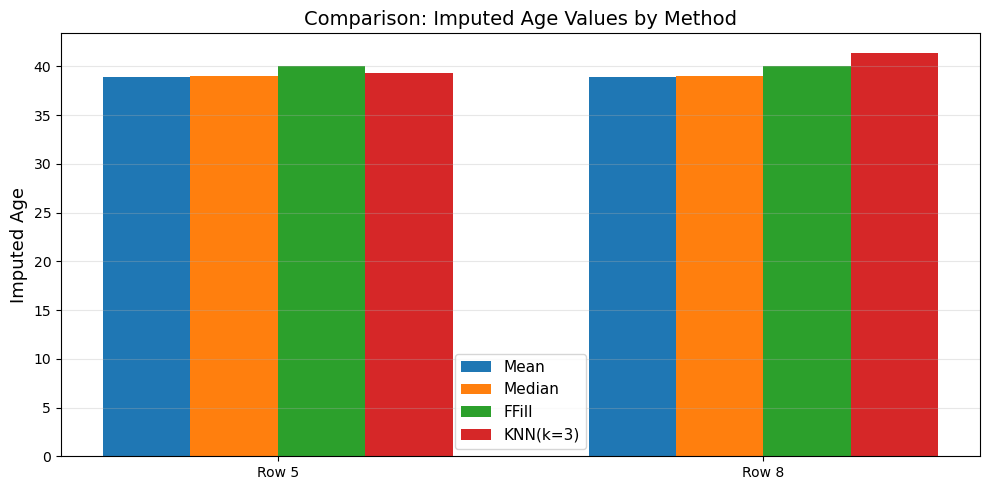

In [83]:
# Collect imputed values for the missing Age rows (index 5, 8)
missing_idx = df_raw[df_raw['Age'].isna()].index.tolist()
methods = {}

# Mean
d = df_raw.copy(); d['Age'].fillna(d['Age'].mean(), inplace=True)
methods['Mean'] = [d.loc[i, 'Age'] for i in missing_idx]

# Median
d = df_raw.copy(); d['Age'].fillna(d['Age'].median(), inplace=True)
methods['Median'] = [d.loc[i, 'Age'] for i in missing_idx]

# Forward Fill
d = df_raw.copy(); d['Age'] = d['Age'].ffill()
methods['FFill'] = [d.loc[i, 'Age'] for i in missing_idx]

# KNN
d = df_raw.copy()
d = pd.get_dummies(d, prefix=['Country'], columns=['Country'], drop_first=True, dtype=float)
d = pd.get_dummies(d, prefix=['Purchased'], columns=['Purchased'], drop_first=True, dtype=float)

knn = KNNImputer(n_neighbors=3)
d_filled = pd.DataFrame(knn.fit_transform(d), columns=d.columns)
methods['KNN(k=3)'] = [d_filled.loc[i, 'Age'] for i in missing_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(missing_idx))
width = 0.18
for j, (name, vals) in enumerate(methods.items()):
    ax.bar(x + j*width, vals, width, label=name)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels([f'Row {i}' for i in missing_idx])
ax.set_ylabel('Imputed Age', fontsize=13)
ax.set_title('Comparison: Imputed Age Values by Method', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---
#### **4 - Applied Imputation: Construction Site Weather Data**

Now let's apply what we learned to a more realistic dataset with **mixed data types** (numeric + categorical) and **various missing patterns**.

##### **4.0 Dataset**

<font color='blue'>**Example) Create a construction-site weather monitoring dataset**</font>

In [84]:
data = {
    'Date': ['08-01','08-02','08-03','08-04','08-05','08-06','08-07','08-08','08-09','08-10',
            '08-11','08-12','08-13','08-14','08-15','08-16','08-17','08-18','08-19','08-20'],
    'Weekday': [0,1,2,3,4,5,6,0,1,2,3,4,5,6,0,1,2,3,4,5],
    'Holiday': [0,0,0,0,np.nan,0,0,0,0,1,0,np.nan,0,0,0,0,0,0,0,0],
    'Temp': [25.1,26.4,np.nan,24.1,24.7,26.5,27.6,28.2,27.1,26.7,np.nan,24.3,23.1,22.4,np.nan,26.5,28.6,np.nan,27.0,26.9],
    'Humidity': [99,np.nan,96,68,98,98,78,np.nan,70,75,np.nan,77,77,89,80,88,76,np.nan,73,73],
    'Wind': [0,0,0,0,0,0,0,0,0,np.nan,0,0,1,1,1,1,0,np.nan,1,0],
    'Outlook': ['rainy','sunny','rainy','overcast','rainy',np.nan,'rainy','rainy','overcast','sunny',
               np.nan,'overcast','sunny','rainy','sunny','rainy',np.nan,'rainy','overcast','sunny'],
    'Crowdedness': [0.14,np.nan,0.21,0.68,0.20,0.32,0.72,0.61,np.nan,0.54,
                   np.nan,0.67,0.66,0.38,0.46,np.nan,0.52,np.nan,0.62,0.81]
}
df = pd.DataFrame(data)

print(f'Shape: {df.shape}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print()
df

Shape: (20, 8)

Missing values:
Date           0
Weekday        0
Holiday        2
Temp           4
Humidity       4
Wind           2
Outlook        3
Crowdedness    5
dtype: int64



,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.1,99.0,0.0,rainy,0.14
1,08-02,1,0.0,26.4,NaN,0.0,sunny,NaN
2,08-03,2,0.0,NaN,96.0,0.0,rainy,0.21
3,08-04,3,0.0,24.1,68.0,0.0,overcast,0.68
4,08-05,4,NaN,24.7,98.0,0.0,rainy,0.20
5,08-06,5,0.0,26.5,98.0,0.0,NaN,0.32
6,08-07,6,0.0,27.6,78.0,0.0,rainy,0.72
7,08-08,0,0.0,28.2,NaN,0.0,rainy,0.61
8,08-09,1,0.0,27.1,70.0,0.0,overcast,NaN
9,08-10,2,1.0,26.7,75.0,NaN,sunny,0.54


##### **4.1 Listwise Deletion (Removing Heavily Missing Rows)**

<font color='blue'>**Example) Remove rows with 4 or more missing values**</font>

In [85]:
missing_per_row = df.isnull().sum(axis=1)
print('Missing values per row:')
print(missing_per_row[missing_per_row > 0])

# Keep rows with < 4 missing values
df_clean = df[missing_per_row < 4].copy()
print(f'\nRows before: {len(df)} → after: {len(df_clean)}')

Missing values per row:
1     2
2     1
4     1
5     1
7     1
8     1
9     1
10    4
11    1
14    1
15    1
16    1
17    4
dtype: int64

Rows before: 20 → after: 18


##### **4.2 Simple Imputation: Mean and Mode**

<font color='blue'>**Example) Fill Humidity with mean, Holiday with mode**</font>

In [86]:
# Humidity → mean (continuous variable)
humidity_mean = df_clean['Humidity'].mean()
df_clean['Humidity'] = df_clean['Humidity'].fillna(humidity_mean)
print(f'Humidity filled with mean = {humidity_mean:.1f}')

# Holiday → mode (binary/categorical variable)
holiday_mode = df_clean['Holiday'].mode()[0]
df_clean['Holiday'] = df_clean['Holiday'].fillna(holiday_mode)
print(f'Holiday filled with mode = {holiday_mode}')

Humidity filled with mean = 82.2
Holiday filled with mode = 0.0


##### **4.3 Linear Interpolation**

Best for **continuous time-series** where values change smoothly over time.

<font color='red'>**Exercise 4.1) Fill missing `Temp` values using linear interpolation.**</font>

In [87]:
# Before
print('Temp before interpolation:')
print(df_clean['Temp'].values)

df_clean['Temp'] = df_clean['Temp'].interpolate(method='linear')

print('\nTemp after interpolation:')
print(df_clean['Temp'].values)

Temp before interpolation:
[25.1 26.4  nan 24.1 24.7 26.5 27.6 28.2 27.1 26.7 24.3 23.1 22.4  nan
 26.5 28.6 27.  26.9]

Temp after interpolation:
[25.1  26.4  25.25 24.1  24.7  26.5  27.6  28.2  27.1  26.7  24.3  23.1
 22.4  24.45 26.5  28.6  27.   26.9 ]


##### **4.4 Forward Fill / Backward Fill (for Categorical Data)**

<font color='red'>**Exercise 4.2) Fill missing `Outlook` using forward fill, then create a second version with backward fill.**</font>

In [88]:
# Forward fill
df_clean['Outlook_ffill'] = df_clean['Outlook'].fillna(method='ffill')

# Backward fill
df_clean['Outlook_bfill'] = df_clean['Outlook'].fillna(method='bfill')

# Compare
comparison = df_clean[['Date', 'Outlook', 'Outlook_ffill', 'Outlook_bfill']]
print(comparison[df_clean['Outlook'].isna()])

     Date Outlook Outlook_ffill Outlook_bfill
5   08-06     NaN         rainy         rainy
16  08-17     NaN         rainy      overcast


##### **4.5 KNN Imputation (Multivariate)**

<font color='red'>**Exercise 4.3) Apply KNN imputation (k=3) to fill `Wind` and `Crowdedness` using all available numerical features.**</font>

In [89]:
from sklearn.impute import KNNImputer

# One-hot encode Outlook for KNN
outlook_ffill_encoded = pd.get_dummies(df_clean['Outlook_ffill'], prefix='Outlook_ffill')
outlook_bfill_encoded = pd.get_dummies(df_clean['Outlook_bfill'], prefix='Outlook_bfill')

# Prepare numerical features
num_features = ['Weekday', 'Holiday', 'Temp', 'Humidity']
knn_input = pd.concat([df_clean[num_features], 
                       outlook_ffill_encoded,
                       outlook_bfill_encoded,
                       df_clean[['Wind', 'Crowdedness']]], axis=1)

# Apply KNN imputation
knn_imputer = KNNImputer(n_neighbors=3)
knn_result = pd.DataFrame(
    knn_imputer.fit_transform(knn_input),
    columns=knn_input.columns,
    index=knn_input.index
)

# Update the columns
df_clean['Wind'] = knn_result['Wind']
df_clean['Crowdedness'] = knn_result['Crowdedness']

# Extract Outlook
for idx in df_clean[df_clean['Outlook'].isna()].index:
    ffill_val = df_clean.loc[idx, 'Outlook_ffill']
    bfill_val = df_clean.loc[idx, 'Outlook_bfill']
    
    if ffill_val == bfill_val:
        # 둘이 같으면 그냥 사용
        df_clean.loc[idx, 'Outlook'] = ffill_val
        print(f'행 {idx}: ffill=bfill={ffill_val} → {ffill_val} 사용')
    else:
        # 다르면 KNN 결과 사용
        ffill_cols = [col for col in knn_result.columns if col.startswith('Outlook_ffill')]
        bfill_cols = [col for col in knn_result.columns if col.startswith('Outlook_bfill')]
        
        # ffill, bfill KNN 결과 합산
        knn_ffill = knn_result.loc[idx, ffill_cols]
        knn_bfill = knn_result.loc[idx, bfill_cols]
        
        # 컬럼명에서 prefix 제거 후 합산
        knn_ffill.index = knn_ffill.index.str.replace('Outlook_ffill_', '')
        knn_bfill.index = knn_bfill.index.str.replace('Outlook_bfill_', '')
        
        combined = knn_ffill + knn_bfill
        result = combined.idxmax()
        
        df_clean.loc[idx, 'Outlook'] = result
        print(f'행 {idx}: ffill={ffill_val}, bfill={bfill_val} → KNN 결과: {result} 사용')

print('\nRemaining missing values:')
print(df_clean[['Wind', 'Crowdedness', 'Outlook']].isnull().sum())

행 5: ffill=bfill=rainy → rainy 사용
행 16: ffill=rainy, bfill=overcast → KNN 결과: overcast 사용

Remaining missing values:
Wind           0
Crowdedness    0
Outlook        0
dtype: int64


##### **4.6 Final Verification**

<font color='red'>**Exercise 4.4) Verify that ALL missing values have been handled. Print the total missing count.**</font>

In [90]:
total_missing = df_clean.isnull().sum().sum()
print(f'Total remaining missing values: {total_missing}')

if total_missing == 0:
    print('✅ All missing values have been successfully imputed!')
else:
    print('⚠️ Some missing values remain:')
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Total remaining missing values: 0
✅ All missing values have been successfully imputed!


---
#### **5 - Summary: Choosing the Right Method**

| Method | Type | Data Type | Time-Series? | Preserves Relationships? |
|--------|------|-----------|--------------|-------------------------|
| Mean | Univariate | Continuous | No | No |
| Median | Univariate | Continuous (with outliers) | No | No |
| Mode | Univariate | Categorical / Discrete | No | No |
| Forward/Backward Fill | Univariate | Any | ✅ Yes | Partially |
| Linear Interpolation | Univariate | Continuous | ✅ Yes | Partially |
| Rolling Mean | Univariate | Continuous | ✅ Yes | Partially |
| KNN | Multivariate | Numeric | No | ✅ Yes |
| MICE (Iterative) | Multivariate | Numeric | No | ✅ Yes |

---
##### **Reference**
- scikit-learn: [Imputation of Missing Values](https://scikit-learn.org/stable/modules/impute.html)
- [The Fundamentals of EDA](https://www.analyticsvidhya.com/blog/2021/11/fundamentals-of-exploratory-data-analysis/)
- [Two Handy Alternatives to Pandas describe()](https://blog.dailydoseofds.com/) — Skimpy, SummaryTools
- [Automated EDA Tool Stack](https://blog.dailydoseofds.com/) — sweetviz, ydata-profiling

---
**📌 Submission**: Complete all exercises → `Restart Kernel and Run All` → Save (`Ctrl+S`) → Submit via e-campus.